## Parte I: Diagnóstico de Cartera y Comportamiento del Cliente

**ID-Cliente:** Identificador ´unico del solicitante (Alfanumérico).  
**Ingreso-Mensual (X):** Ingreso neto reportado en miles de USD.  
**Tipo-Vivienda (V):** Variable categ´orica con dos niveles: Propia o Alquilada.  
**Mora-Previa (M):** Variable binaria que indica si el cliente ha tenido retrasos en pagos anteriores (1 = S´ı, 0 = No).  
**Estado-Credito (C):** Etiqueta de clasificaci´on que representa el evento de interés.
Puntaje  
    - *C =1(Evento A):* El cliente incumpli´o con el pago (Default).  
    - *C =0(Evento Ac):* El cliente pag´o exitosamente la totalidad del cr´edito.  
**Psicometrico (S):** Un´ındice continuo (0 a 100) basado en un test de comportamiento frente al riesgo. Se busca modelar su función de densidad para entender la separaci´on entre clientes aptos y no aptos.

In [5]:
#Cargar librerías y datos:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import gaussian_kde

df = pd.read_csv("data/raw/credit_risk_data.csv")

print(df.head())
print("Dimensiones del df: ",df.shape)

  ID_Cliente  Ingreso_Mensual Tipo_Vivienda  Mora_Previa  Estado_Credito  \
0   FT-00001             2.21        Propia            0               0   
1   FT-00002             2.49     Alquilada            0               1   
2   FT-00003             5.65        Propia            0               0   
3   FT-00004             3.82     Alquilada            0               0   
4   FT-00005             5.08     Alquilada            1               0   

   Puntaje_Psicometrico  
0                    72  
1                    33  
2                    63  
3                    71  
4                    59  
Dimensiones del df:  (10000, 6)


### Pregunta 1: Segmentación de Vivienda e Inestabilidad
1. ¿Qué tan representativo es el grupo de clientes que viven en arriendo pero que logran cumplir con sus obligaciones financieras respecto al total de la cartera?

Primero se deben definir el conjunto y los subconjuntos que conforman el dataset como anteriormente se definió:

- **Ω** = 10.000 solicitantes para el crédito.
- **V** = {Cliente vive en vivienda Alquilada}
- **A** = {Cliente entra en Default} → `Estado_Credito = 1`
- **Aᶜ** = {Cliente paga exitosamente} → `Estado_Credito = 0`

Ahora para responder esta pregunta, en términos de conjuntos se ve como la intersección de ambos subconjuntos: $V \cap Aᶜ$



In [13]:
#Casos totales
n = len(df)

#Casos favorables: alquilan y pagan exitosamente
n_alq_paga   = len(df[(df['Tipo_Vivienda'] == 'Alquilada') & (df['Estado_Credito'] == 0)])

#Calculo de la probabilidad
p_alq_paga    = n_alq_paga   / n


print(f'Clientes que alquilan Y pagan exitosamente: {n_alq_paga}')
print(f'P(V ∩ Aᶜ) = {n_alq_paga} / {n} = {p_alq_paga:.4f}  ≈  {p_alq_paga*100:.2f}%')

Clientes que alquilan Y pagan exitosamente: 2913
P(V ∩ Aᶜ) = 2913 / 10000 = 0.2913  ≈  29.13%


2. ¿Qué proporción de la base de datos total est´a compuesta por clientes que alquilan su vivienda y adem´as presentan
un estado de default?

En términos de conjutos se ve como la intersección de dos subconjuntos: $V \cap A$

In [8]:
#Casos favorables: alquilan y no pagan exitosamente
n_alq_default = len(df[(df['Tipo_Vivienda'] == 'Alquilada') & (df['Estado_Credito'] == 1)])

#Calculo de la probabilidad
p_alq_default = n_alq_default / n

print(f'Clientes que alquilan Y están en default: {n_alq_default}')
print(f'P(V ∩ A) = {n_alq_default} / {n} = {p_alq_default:.4f}  ≈  {p_alq_default*100:.2f}%')

Clientes que alquilan Y están en default: 769
P(V ∩ A) = 769 / 10000 = 0.0769  ≈  7.69%


**Reflexión:**
 Si usted fuera el director de estrategia, ¿consideraría que el hecho de vivir en arriendo es un indicador suficiente para denegar un crédito de forma autom´atica? Utilice los valores obtenidos para sustentar su postura.

Para dar respuesta a esta pregunta, podemos comparar con las personas que tienen vivienda propia y de acuerdo a su estado de pagos exitosos o no (*default*).

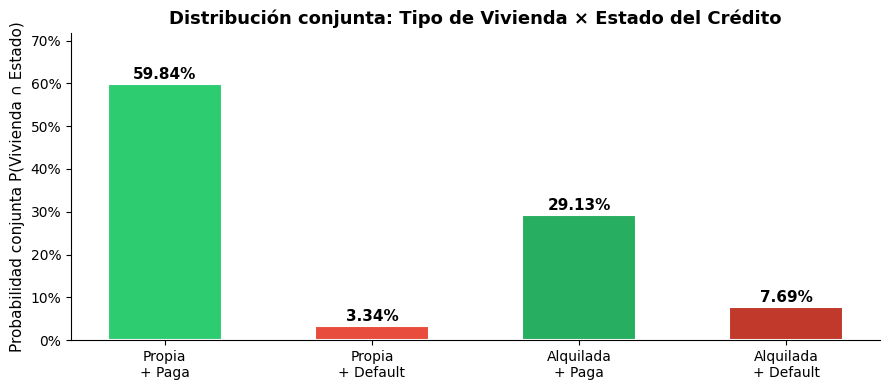

In [9]:
import matplotlib.patches as mpatches

categorias = ['Propia\n+ Paga', 'Propia\n+ Default', 'Alquilada\n+ Paga', 'Alquilada\n+ Default']
valores = [
    len(df[(df['Tipo_Vivienda']=='Propia')    & (df['Estado_Credito']==0)]) / n,
    len(df[(df['Tipo_Vivienda']=='Propia')    & (df['Estado_Credito']==1)]) / n,
    p_alq_paga,
    p_alq_default
]
colores = ['#2ecc71','#e74c3c','#27ae60','#c0392b']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(categorias, valores, color=colores, edgecolor='white', linewidth=1.5, width=0.55)
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Probabilidad conjunta P(Vivienda ∩ Estado)', fontsize=11)
ax.set_title('Distribución conjunta: Tipo de Vivienda × Estado del Crédito', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(valores)*1.2)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

*¿Es vivir en arriendo un indicador suficiente para denegar crédito automáticamente?*

*No.* Los datos muestran que:

- El **29.13%** de toda la cartera son arrendatarios que **pagan exitosamente** → son clientes valiosos y fidelizables.
- Solo el **7.69%** son arrendatarios que incumplen (el *riesgo crítico* del área de cobranza).

Denegar crédito a todos los arrendatarios implicaría rechazar automáticamente casi el **37%** de la cartera total, de los cuales la gran mayoría (≈ 79%) son buenos pagadores. Una política tan rígida sería económicamente ineficiente y potencialmente discriminatoria. Lo correcto es usar el tipo de vivienda como **una variable más** en un modelo multivariado, no como criterio único de decisión.

### Pregunta 2: El Peso del Pasado

1. Si seleccionamos al azar a un cliente que sabemos que tiene antecedentes de mora (Mora-Previa = 1), ¿cuál es la probabilidad de que este cliente termine efectivamente en default en su crédito actual?

Esta pregunta se responde con una probabilidad condicional: 

$$P(A \mid M = 1) = \frac{P(A \cap M)}{P(M)}, \quad \text{con } P(M) > 0$$



In [ ]:
# Probabilidad condicional: P(Default | Mora = 1) 
mora_si = df[df['Mora_Previa'] == 1]

# P(Default | Mora = 1)
p_def_dado_mora    = (mora_si['Estado_Credito'] == 1).sum() / len(mora_si)

print(f'Clientes con mora previa:          {len(mora_si)}')
print(f'De ellos, en default:              {(mora_si["Estado_Credito"]==1).sum()}')
print(f'P(Default | Mora=1) = {p_def_dado_mora:.4f}  →  {p_def_dado_mora*100:.2f}%')

Clientes con mora previa:          1198
De ellos, en default:              629
P(Default | Mora=1) = 0.5250  →  52.50%


2. Compare este resultado con la probabilidad de default de un cliente del que no tenemos información previa de mora.

Esta pregunta se responde con una probabilidad condicional: 

$$P(A \mid M = 0) = \frac{P(A \cap M)}{P(M)}, \quad \text{con } P(M) > 0$$


In [11]:
#Probabilidad condicional: P(Default | Mora = 0) 
mora_no = df[df['Mora_Previa'] == 0]

# P(Default | Mora = 0)
p_def_dado_no_mora = (mora_no['Estado_Credito'] == 1).sum() / len(mora_no)

print(f'Clientes SIN mora previa:          {len(mora_no)}')
print(f'De ellos, en default:              {(mora_no["Estado_Credito"]==1).sum()}')
print(f'P(Default | Mora=0) = {p_def_dado_no_mora:.4f}  →  {p_def_dado_no_mora*100:.2f}%')

Clientes SIN mora previa:          8802
De ellos, en default:              474
P(Default | Mora=0) = 0.0539  →  5.39%


**Reflexión:**
¿Es la Mora-Previa un predictor determinante o un distractor estadístico? ¿Cómo cambia su percepción del riesgo de un solicitante cuando este antecedente entra en la ecuación?

Para responder está pregunta debemos evaluar el riesgo que representa la mora previa o no, además de la probabilidad de que no se tengan pagos existosos (*default*) sin condiciones previas.

P(Default) marginal (sin condición) = 0.1103  →  11.03%

Factor de riesgo: tener mora previa multiplica el riesgo por 9.7x


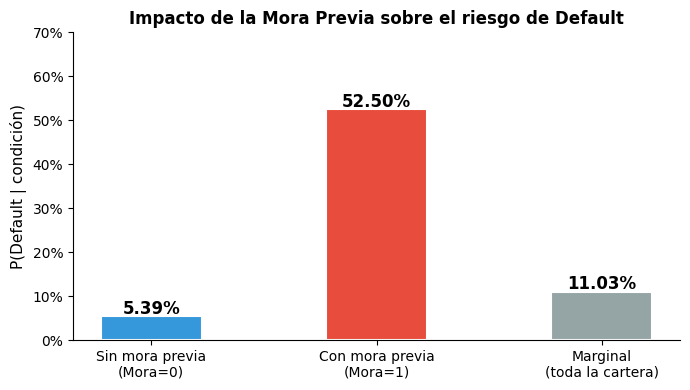

In [12]:
# P(Default) marginal
p_def_marginal     = (df['Estado_Credito'] == 1).sum() / n

print(f'P(Default) marginal (sin condición) = {p_def_marginal:.4f}  →  {p_def_marginal*100:.2f}%')
print(f'\nFactor de riesgo: tener mora previa multiplica el riesgo por {p_def_dado_mora/p_def_dado_no_mora:.1f}x')



# ── Visualización comparativa ──
fig, ax = plt.subplots(figsize=(7, 4))
grupos  = ['Sin mora previa\n(Mora=0)', 'Con mora previa\n(Mora=1)', 'Marginal\n(toda la cartera)']
probs   = [p_def_dado_no_mora, p_def_dado_mora, p_def_marginal]
colores = ['#3498db', '#e74c3c', '#95a5a6']

bars = ax.bar(grupos, probs, color=colores, width=0.45, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, probs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.2%}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('P(Default | condición)', fontsize=11)
ax.set_title('Impacto de la Mora Previa sobre el riesgo de Default', fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.7)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

La mora previa es un **predictor muy determinante**, no un distractor. Pasar de no tener mora a tenerla **multiplica la probabilidad de default por casi 10x** (de 5.39% a 52.50%). 

Sin embargo, no es un predictor perfecto: el 47.5% de los clientes con mora previa *sí pagan* en esta ocasión. Esto sugiere que la mora previa debe elevar la señal de alerta y justificar condiciones más estrictas, como un menor monto, pero no necesariamente la denegación automática. En la práctica se combina con otras variables para un score más robusto.

### Pregunta 3: El Dilema del Analista
¿Qué tan probable es que este cliente que nos acaba de incumplir ya hubiera tenido problemas de mora en el pasado?

**Tarea:** Calcule la probabilidad de que un cliente tenga antecedentes de mora, dado que se encuentra en estado de default.
Utilice para ello los componentes del Teorema de Bayes derivados de la base de datos.

Basandonos en la condición calculada en la pregunta pasada, podemos aplicar Teorema de Bayes para calcular esa probabilidad.

El **Teorema de Bayes** permite invertir la dirección de la condicionalidad:

$$P(M=1 \mid A) = \frac{P(A \mid M=1) \cdot P(M=1)}{P(A)}$$

donde la probabilidad total del denominador se expande como:

$$P(A) = P(A \mid M=1) \cdot P(M=1) + P(A \mid M=0) \cdot P(M=0)$$

Identificamos:
- **Prior** → $P(M=1)$: probabilidad base de mora previa en la cartera
- **Verosimilitud** → $P(A \mid M=1)$: calculada en la Pregunta 2
- **Evidencia** → $P(A)$: probabilidad marginal de default
- **Posterior** → $P(M=1 \mid A)$: lo que queremos calcular

In [17]:
p_mora   = len(mora_si) / n                        # P(M=1) prior
p_no_mora = len(mora_no) / n                       # P(M=0)

# Verosimilitudes (calculadas en Pregunta 2)
# p_def_dado_mora     → P(A | M=1)
# p_def_dado_no_mora  → P(A | M=0)

# Probabilidad total de default (ley de probabilidad total)
p_def_total = p_def_dado_mora * p_mora + p_def_dado_no_mora * p_no_mora

# Posterior: P(M=1 | Default) — Bayes
p_mora_dado_def = (p_def_dado_mora * p_mora) / p_def_total

print('Componentes del Teorema de Bayes:')
print(f'  Prior         P(M=1)         = {p_mora:.4f}  ({p_mora*100:.2f}%)')
print(f'  Prior         P(M=0)         = {p_no_mora:.4f}  ({p_no_mora*100:.2f}%)')
print(f'  Verosimilitud    P(A | M=1)     = {p_def_dado_mora:.4f}  ({p_def_dado_mora*100:.2f}%)')
print(f'  Verosimilitud    P(A | M=0)     = {p_def_dado_no_mora:.4f}  ({p_def_dado_no_mora*100:.2f}%)')
print(f'  Evidencia     P(A)           = {p_def_total:.4f}  ({p_def_total*100:.2f}%)')
print()
print('Resultado:')
print(f'  Posterior  P(M=1 | Default)  = {p_mora_dado_def:.4f}  ({p_mora_dado_def*100:.2f}%)')

print()
print('Interpretación: De cada 100 clientes en default,',f'aproximadamente {p_mora_dado_def*100:.0f} ya tenían mora previa registrada.')


Componentes del Teorema de Bayes:
  Prior         P(M=1)         = 0.1198  (11.98%)
  Prior         P(M=0)         = 0.8802  (88.02%)
  Verosimilitud    P(A | M=1)     = 0.5250  (52.50%)
  Verosimilitud    P(A | M=0)     = 0.0539  (5.39%)
  Evidencia     P(A)           = 0.1103  (11.03%)

Resultado:
  Posterior  P(M=1 | Default)  = 0.5703  (57.03%)

Interpretación: De cada 100 clientes en default, aproximadamente 57 ya tenían mora previa registrada.


**Reflexión:**

Con **P(M=1 | Default) ≈ 57%**, más de la mitad de los clientes en default tenían mora previa. Esto **no significa causalidad directa**: el 43% restante son incumplimientos de clientes sin antecedentes, lo que evidencia que existen **factores externos** (pérdida de empleo, emergencias, ciclos económicos) que afectan incluso a clientes con historial impecable.

La mora previa es una señal fuerte pero no determinante. Un modelo de riesgo robusto debe complementarla con variables como el ingreso, el puntaje psicométrico y el tipo de vivienda.